Setup:

In [1]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import gc
gc.collect()


28

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

tokenizer = AutoTokenizer.from_pretrained('meta-llama/Meta-Llama-3-8B', use_fast=True)
model = AutoModelForCausalLM.from_pretrained('meta-llama/Meta-Llama-3-8B', dtype=torch.bfloat16, device_map="auto")
model.seqlen = model.config.max_position_embeddings

/home/mrajnoha/double-block-sparse/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 291/291 [00:11<00:00, 25.40it/s] 


In [3]:
import torch.nn as nn

def find_layers(module, layers=[nn.Conv2d, nn.Linear], name=''):
    if type(module) in layers and "lm_head" not in name:
        return {name: module}
    res = {}
    for name1, child in module.named_children():
        res.update(find_layers(
            child, layers=layers, name=name + '.' + name1 if name != '' else name1
        ))
    return res

find_layers(model)

{'model.layers.0.self_attn.q_proj': Linear(in_features=4096, out_features=4096, bias=False),
 'model.layers.0.self_attn.k_proj': Linear(in_features=4096, out_features=1024, bias=False),
 'model.layers.0.self_attn.v_proj': Linear(in_features=4096, out_features=1024, bias=False),
 'model.layers.0.self_attn.o_proj': Linear(in_features=4096, out_features=4096, bias=False),
 'model.layers.0.mlp.gate_proj': Linear(in_features=4096, out_features=14336, bias=False),
 'model.layers.0.mlp.up_proj': Linear(in_features=4096, out_features=14336, bias=False),
 'model.layers.0.mlp.down_proj': Linear(in_features=14336, out_features=4096, bias=False),
 'model.layers.1.self_attn.q_proj': Linear(in_features=4096, out_features=4096, bias=False),
 'model.layers.1.self_attn.k_proj': Linear(in_features=4096, out_features=1024, bias=False),
 'model.layers.1.self_attn.v_proj': Linear(in_features=4096, out_features=1024, bias=False),
 'model.layers.1.self_attn.o_proj': Linear(in_features=4096, out_features=4096

In [4]:
model.hf_device_map

{'model.embed_tokens': 0,
 'model.layers.0': 0,
 'model.layers.1': 0,
 'model.layers.2': 0,
 'model.layers.3': 0,
 'model.layers.4': 0,
 'model.layers.5': 0,
 'model.layers.6': 0,
 'model.layers.7': 0,
 'model.layers.8': 0,
 'model.layers.9': 0,
 'model.layers.10': 0,
 'model.layers.11': 0,
 'model.layers.12': 0,
 'model.layers.13': 0,
 'model.layers.14': 1,
 'model.layers.15': 1,
 'model.layers.16': 1,
 'model.layers.17': 1,
 'model.layers.18': 1,
 'model.layers.19': 1,
 'model.layers.20': 1,
 'model.layers.21': 1,
 'model.layers.22': 1,
 'model.layers.23': 1,
 'model.layers.24': 1,
 'model.layers.25': 1,
 'model.layers.26': 1,
 'model.layers.27': 1,
 'model.layers.28': 1,
 'model.layers.29': 1,
 'model.layers.30': 1,
 'model.layers.31': 1,
 'model.norm': 1,
 'model.rotary_emb': 1,
 'lm_head': 1}

In [5]:
from transformers import TextStreamer

def test_perplexity_and_response(model, tokenizer):
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    text = 'The quick brown fox jumps over the lazy dog.'
    inputs = tokenizer(text, return_tensors='pt', padding=True).to('cuda')

    with torch.no_grad(), torch.autocast('cuda', dtype=torch.bfloat16):
        outputs = model(**inputs, labels=inputs['input_ids'])
        loss = outputs.loss
        perplexity = torch.exp(loss.float()).item()

    print(f'Loss: {loss.item():.4f}')
    print(f'Perplexity: {perplexity:.4f}\n')

    print('Model response: ', end='')
    streamer = TextStreamer(tokenizer, skip_prompt=True)
    model.generate(
        **inputs, 
        streamer=streamer, 
        max_new_tokens=20,
        pad_token_id=tokenizer.pad_token_id,
        do_sample=True,
        temperature=0.7
    )

In [6]:
length = 0
for name, param in model.named_parameters():
    if 'proj' in name:
        print(name, param.shape)
        length += 1
print(f'Matrix count: {length}')

model.layers.0.self_attn.q_proj.weight torch.Size([4096, 4096])
model.layers.0.self_attn.k_proj.weight torch.Size([1024, 4096])
model.layers.0.self_attn.v_proj.weight torch.Size([1024, 4096])
model.layers.0.self_attn.o_proj.weight torch.Size([4096, 4096])
model.layers.0.mlp.gate_proj.weight torch.Size([14336, 4096])
model.layers.0.mlp.up_proj.weight torch.Size([14336, 4096])
model.layers.0.mlp.down_proj.weight torch.Size([4096, 14336])
model.layers.1.self_attn.q_proj.weight torch.Size([4096, 4096])
model.layers.1.self_attn.k_proj.weight torch.Size([1024, 4096])
model.layers.1.self_attn.v_proj.weight torch.Size([1024, 4096])
model.layers.1.self_attn.o_proj.weight torch.Size([4096, 4096])
model.layers.1.mlp.gate_proj.weight torch.Size([14336, 4096])
model.layers.1.mlp.up_proj.weight torch.Size([14336, 4096])
model.layers.1.mlp.down_proj.weight torch.Size([4096, 14336])
model.layers.2.self_attn.q_proj.weight torch.Size([4096, 4096])
model.layers.2.self_attn.k_proj.weight torch.Size([1024,

In [7]:
q_proj_weight = model.model.layers[3].self_attn.q_proj.weight
print(q_proj_weight.shape)   # torch.Size([4096, 4096])
print(q_proj_weight)

k_proj_weight = model.model.layers[5].self_attn.k_proj.weight
print(k_proj_weight.shape)   # torch.Size([4096, 4096])
print(k_proj_weight)

torch.Size([4096, 4096])
Parameter containing:
tensor([[ 0.0092,  0.0076,  0.0015,  ...,  0.0166,  0.0034,  0.0076],
        [ 0.0125,  0.0153,  0.0129,  ..., -0.0004,  0.0128,  0.0056],
        [ 0.0192,  0.0037, -0.0167,  ...,  0.0115,  0.0078, -0.0008],
        ...,
        [-0.0164,  0.0254,  0.0026,  ...,  0.0089, -0.0062,  0.0029],
        [-0.0457,  0.0171, -0.0064,  ..., -0.0184, -0.0020, -0.0018],
        [-0.0135, -0.0003, -0.0234,  ..., -0.0082,  0.0088,  0.0267]],
       device='cuda:0', dtype=torch.bfloat16, requires_grad=True)
torch.Size([1024, 4096])
Parameter containing:
tensor([[-0.0021,  0.0483, -0.0437,  ...,  0.0026, -0.0344,  0.0060],
        [ 0.0170,  0.0552,  0.0059,  ...,  0.0112,  0.0259,  0.0011],
        [-0.0035,  0.0186, -0.0403,  ...,  0.0056, -0.0273,  0.0025],
        ...,
        [ 0.0164, -0.0613,  0.0312,  ...,  0.0625,  0.0381, -0.0449],
        [ 0.0226, -0.0013,  0.0204,  ..., -0.0031, -0.0077,  0.0295],
        [ 0.0547, -0.0003, -0.0090,  ...,  

In [8]:
from typing import Literal
import math
import time

from einops import rearrange
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np

torch.cuda.empty_cache()
torch.cuda.synchronize()


In [9]:
from matplotlib.colors import ListedColormap

def plot_masks(mask_a, mask_b, mask_type):
    cmap = ListedColormap(['gray', 'lime'])
    _, axs = plt.subplots(1, 2, figsize=(8, 4))

    for ax, mask, title in zip(
        axs,
        [mask_a[:16, :16], mask_b[:16, :16]],
        ['mask_a', 'mask_b']
    ):
        _ = ax.imshow(mask, cmap=cmap, vmin=0, vmax=1)

        ax.set_xticks(np.arange(-0.525, 16, 1), minor=True,)
        ax.set_yticks(np.arange(-0.55, 16, 1), minor=True)
        ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5)

        if mask_type == '2to4':
            for x in np.arange(-0.5, 16, 4):
                ax.axvline(x=x, color='deepskyblue', linewidth=1.5)
            for y in np.arange(-0.5, 16, 1):
                ax.axhline(y=y, color='deepskyblue', linewidth=1.5)

        ax.set_title(title)

    plt.tight_layout()
    plt.show()

In [10]:
print(q_proj_weight.device)
print(q_proj_weight.dtype)

print(k_proj_weight.device)
print(k_proj_weight.dtype)

cuda:0
torch.bfloat16
cuda:0
torch.bfloat16


Mask functions:

In [11]:
def mag_prune(W, sp=0.5):
    thres = (W).abs().flatten().sort()[0][int(W.numel() * sp)]
    mask = ((W).abs() > thres)
    return W * mask

In [12]:
def _mag_prune_mask(W, sp=0.6):
    thres = (W).abs().flatten().sort()[0][int(W.numel() * sp)]
    mask = ((W).abs() > thres)
    return mask

In [13]:
def _block_mask(
    W_hat: torch.Tensor,
    U: torch.Tensor,
    bsparsity: float,
    rows: int, cols: int
) -> torch.Tensor:
    h, w = W_hat.shape

    blocks = (W_hat + U).reshape(h // rows, rows, w // cols, cols)
    block_norms_sq = blocks \
                        .pow(2) \
                        .sum(dim=(1, 3))  # sqrt skipped as it has no effect

    # pick top blocks
    flat = block_norms_sq.flatten()
    k = max(1, int(bsparsity * flat.numel()))
    thres = torch.kthvalue(flat, k).values

    # expand back
    block_mask = block_norms_sq > thres
    return block_mask.repeat_interleave(rows, dim=0).repeat_interleave(cols, dim=1)


In [14]:
def default_block_mask(W_hat, U, bsparsity):
    return _block_mask(W_hat, U, bsparsity, 2, 2)

In [15]:
def _get_mask_2_to_4(
    W_hat: torch.Tensor, 
    U: torch.Tensor,
    bsparsity: float,
    transpose: bool = True
) -> torch.Tensor:

    W_U_sum = W_hat + U
    if transpose:
        W_U_sum = W_U_sum.T
    rows = W_U_sum.shape[0]
    thres = int(W_U_sum.numel() * (1 - bsparsity)) # 16% or 24% of elements

    # create groups of 4 and sort the 4 elements in each one
    W_U_sum_grouped = W_U_sum.reshape(rows, -1, 4)
    g_sorted_elements, _ = W_U_sum_grouped.abs().sort(dim=-1, descending=True)
    
    # calculate norms of [top two elements] in each group
    # then sort groups according to the result
    # (we use norm as that performed best in usual block sparsity)
    top2_sums = g_sorted_elements[:, :, :2].norm(dim=-1, p=2)
    _, best_group_ids = top2_sums.flatten().sort(descending=True)
    
    group_take_count = (thres // 4) * 2
    # each group contains 4 elements, so we divide by 4, but 2:4 will be applied,
    # so we multiply by 2 to get the desired sparsity

    # group-wise mask
    # we get locations of groups where the calculated norms are the highest
    # we keep these locations in the mask
    all_groups_count = W_U_sum_grouped.shape[1]
    g_mask = torch.zeros(rows * all_groups_count, dtype=torch.bool, device=W_U_sum.device)
    g_mask[best_group_ids[:group_take_count]] = True
    g_mask = g_mask.reshape(rows, all_groups_count)

    # apply 2:4 in selected groups -> now we get back to 16%/24% sparsity
    # we select top two elements in absolute value as they contribute the most to the norm
    _, ids = W_U_sum_grouped.abs().topk(2, dim=-1, sorted=False)
    mask = torch.zeros_like(W_U_sum_grouped, dtype=torch.bool)
    mask = mask.scatter(-1, ids, True)
    mask = mask & g_mask.unsqueeze(-1) # add dim to zero out the remaining groups
    mask = mask.reshape(rows, -1)
    
    del W_U_sum_grouped, g_sorted_elements, top2_sums, g_mask
    if transpose:
        mask = mask.T
    return mask

Factorization functions:

In [16]:
# penalty factor
RHO = 1

In [17]:
# inner loop of the ||W-AB||_2 minization algorithm
# ADMM is performed for m (iters) iterations
def find_other2(X, W, nnz, Z, U, mask_type, alt=False, reg=0, rho_start=0.03, iters=5, prune_iters=2):
    # Z_0 = identity
    # U_0 = zero matrix
    # X can be:
    # -> A, when we're solving for B (Z) and U_b (U)
    # -> B, when we're solving for A (Z) and U_a (U)
    X, W, Z, U = X.float(), W.float(), Z.float(), U.float()

    # normalization with diag. reg.
    norm2 = torch.linalg.vector_norm(X, dim=0) + 1e-8
    An = X / norm2
    XTX = An.T.matmul(An)
    
    mean_diag = XTX.trace() / XTX.shape[0]
    if reg > 0:
        XTX.diagonal().add_(mean_diag * reg)
    
    rho = RHO
    XTW = An.T.matmul(W)

    # XTX_inv = torch.inverse(XTX + torch.eye(XTX.shape[1], device=XTX.device)*rho)
    # XTX_inv2 = torch.inverse(XTX + torch.eye(XTX.shape[1], device=XTX.device)*rho_start)
    XTX.diagonal().add_(rho_start)
    L2 = torch.linalg.cholesky(XTX)

    XTX.diagonal().add_(rho - rho_start)
    L = torch.linalg.cholesky(XTX)
    ########################

    U = U * norm2.unsqueeze(1)
    Z = Z * norm2.unsqueeze(1)
    
    # W_hat = XTX_inv2.matmul(XTW + rho_start*(Z-U))
    RHS_start = XTW + rho_start * (Z - U)
    W_hat = torch.cholesky_solve(RHS_start, L2)
    ########################

    bsparsity = min(0.99, 1 - nnz/W_hat.numel()) # 0.76 or 0.84

    for itt in range(iters):            
        if itt < prune_iters:
            if not mask_type:
                mask = _mag_prune_mask(W_hat+U, bsparsity)
            if mask_type == 'blocks':
                mask = _block_mask(W_hat=W_hat, U=U, bsparsity=bsparsity, rows=2, cols=2)

            # if mask_type == 'blocks_alt' and not alt:
            #     mask = _block_mask(W_hat=W_hat, U=U, bsparsity=bsparsity, rows=2, cols=1)
            # if mask_type == 'blocks_alt' and alt:
            #     mask = _block_mask(W_hat=W_hat, U=U, bsparsity=bsparsity, rows=1, cols=2)
            if mask_type == 'blocks_alt':
                mask = _block_mask(W_hat=W_hat, U=U, bsparsity=bsparsity, rows=1, cols=2)

            if mask_type == '2to4' and not alt:
                mask = _get_mask_2_to_4(W_hat=W_hat, U=U, bsparsity=bsparsity, transpose=True)
            if mask_type == '2to4' and alt:
                mask = _get_mask_2_to_4(W_hat=W_hat, U=U, bsparsity=bsparsity, transpose=False)

            if mask_type == 'hybrid' and not alt:
                mask = _get_mask_2_to_4(W_hat=W_hat, U=U, bsparsity=bsparsity)
            if mask_type == 'hybrid' and alt:
                mask = _mag_prune_mask(W_hat+U, bsparsity)

        # ADMM iterations
        Z = mask * (W_hat + U)
        U = U + (W_hat - Z)
        # W_hat = XTX_inv.matmul(XTW + rho*(Z-U))
        RHS = XTW + rho * (Z - U)
        W_hat = torch.cholesky_solve(RHS, L)
        ########################

    return (Z) / norm2.unsqueeze(1), U / norm2.unsqueeze(1), mask

In [18]:
import torch
from typing import Literal

def apply_tetris_reordering(A: torch.Tensor, B: torch.Tensor, prune_fn, epsilon: float = 1e-5, max_outer_iters: int = 10, max_inner_iters: int = 100):
    device = A.device
    k = A.shape[1]
    if k != B.shape[0]:
        raise ValueError("Inner dimensions of A and B mismatched.")

    W_cat = torch.cat([A.T, B], dim=1)
    perm = torch.arange(k, device=device)

    for _ in range(max_outer_iters):
        M = prune_fn(W_cat).to(W_cat.dtype)
        swaps_made = 0
        
        for _ in range(max_inner_iters):
            # tensor contraction S = |W|M^T 
            S = torch.matmul(torch.abs(W_cat), M.T) 
            L = torch.diag(S) 
            G = L.unsqueeze(1) + L.unsqueeze(0) - S - S.T
            G.fill_diagonal_(-float('inf'))
            
            max_G_idx = torch.argmax(G)
            i = max_G_idx // k
            j = max_G_idx % k
            max_g_val = G[i, j].item()
            if max_g_val <= epsilon:
                break

            # greedy swap
            w_i = W_cat[i].clone()
            W_cat[i] = W_cat[j]
            W_cat[j] = w_i
            
            p_i = perm[i].clone()
            perm[i] = perm[j]
            perm[j] = p_i

            swaps_made += 1
            
        if swaps_made == 0:
            break
            
    A_perm = A[:, perm]
    B_perm = B[perm, :]
    return A_perm, B_perm, perm

def get_tetris_prune_wrapper(mask_type, bsp_A, bsp_B, cols_A, cols_B, alt=False):
    def prune_func(W_cat):
        A_T_hat = W_cat[:, :cols_A]
        B_hat = W_cat[:, cols_A:]
        U_A_T = torch.zeros_like(A_T_hat)
        U_B = torch.zeros_like(B_hat)
        
        def get_mask(W_h, U_h, bsp, is_alt):
            if not mask_type:
                return _mag_prune_mask(W_h + U_h, bsp)
            if mask_type == 'blocks':
                return _block_mask(W_hat=W_h, U=U_h, bsparsity=bsp, rows=2, cols=2)
            if mask_type == 'blocks_alt':
                return _block_mask(W_hat=W_h, U=U_h, bsparsity=bsp, rows=1, cols=2)
            if mask_type == '2to4':
                return _get_mask_2_to_4(W_hat=W_h, U=U_h, bsparsity=bsp, transpose=not is_alt)
            if mask_type == 'hybrid':
                if not is_alt:
                    return _get_mask_2_to_4(W_hat=W_h, U=U_h, bsparsity=bsp)
                else:
                    return _mag_prune_mask(W_h + U_h, bsp)
            return _mag_prune_mask(W_h + U_h, bsp)

        mask_A_T = get_mask(A_T_hat, U_A_T, bsp_A, is_alt=False)
        mask_B = get_mask(B_hat, U_B, bsp_B, is_alt=alt)
        return torch.cat([mask_A_T, mask_B], dim=1)
        
    return prune_func

In [19]:
def apply_2to4_pruning(tensor, dim=-1):
    shape = tensor.shape
    if dim == 0:
        reshaped = tensor.view(-1, 4, shape[1])
        _, top_idx = reshaped.abs().topk(2, dim=1)
        mask = torch.zeros_like(reshaped, dtype=torch.bool)
        mask.scatter_(1, top_idx, True)
        return (reshaped * mask).view(shape)
    else:
        reshaped = tensor.view(shape[0], -1, 4)
        _, top_idx = reshaped.abs().topk(2, dim=2)
        mask = torch.zeros_like(reshaped, dtype=torch.bool)
        mask.scatter_(2, top_idx, True)
        return (reshaped * mask).view(shape)


def evaluate_permutation_loss(A, B, W, perm_indices):
    A_perm = A[:, perm_indices]
    B_perm = B[perm_indices, :]
    
    A_pruned = apply_2to4_pruning(A_perm, dim=-1)
    B_pruned = apply_2to4_pruning(B_perm, dim=0)
    
    W_approx = A_pruned @ B_pruned
    return abs(float(torch.norm(W_approx - W, p='fro')))


def cluster_perm(A, B, W, iters=200):
    """
    Finds permutation matrix P such that APP^TB
    minimizes the 2:4 reconstruction error against W.
    """
    inner_dim = A.shape[1]
    if inner_dim % 4 != 0:
        raise ValueError("Inner dimension must be divisible by 4 for 2:4 sparsity.")
        
    importance = torch.norm(A, p=2, dim=0) * torch.norm(B, p=2, dim=1)
    sorted_idx = torch.argsort(importance, descending=True) # argsort heuristic init
    
    # interleave groups
    current_perm = torch.zeros_like(sorted_idx)
    groups = inner_dim // 4
    for i in range(inner_dim):
        group_idx = i % groups
        pos_in_group = i // groups
        current_perm[group_idx * 4 + pos_in_group] = sorted_idx[i]
    
    best_loss = evaluate_permutation_loss(A, B, W, current_perm)
    
    # greedy swap
    for i in range(iters):
        if i % 10 == 0:
            print(i)
            
        # pick two random indices to swap
        idx1, idx2 = torch.randint(0, inner_dim, (2,)).tolist()
        if idx1 == idx2: 
            continue
            
        proposed_perm = current_perm.clone()
        proposed_perm[idx1], proposed_perm[idx2] = proposed_perm[idx2], proposed_perm[idx1]
        
        loss = evaluate_permutation_loss(A, B, W, proposed_perm)
        if loss < best_loss:
            best_loss = loss
            current_perm = proposed_perm
            
    P = torch.zeros((inner_dim, inner_dim), device=A.device, dtype=A.dtype)
    P[torch.arange(inner_dim), current_perm] = 1.0
    return P, current_perm, best_loss

In [ ]:
# this finds AB such that ||W-AB||_2 is minimized
# XX is here for LLMs only
def _factorize_init(W, XX, mask_type, bsp=0.25, sp=0.5, mid_dim_scale=1, iters=40):
    original_dtype = W.dtype
    # move to fp32 for factorization
    W = W.float()
    XX = XX.float()
    
    transpose = False
    if W.shape[0] > W.shape[1]: # > ???
        W = W.T
        transpose = True
    
    nza = int(W.shape[0]*W.shape[1] * bsp)
    nzb = int(W.numel() * sp - nza)

    # 'for the pruning of LLMs, we found that it is better
    # to project the weight matrix multiplied
    # by input feature norm'
    if transpose:
        norm = XX.diag().sqrt().unsqueeze(1) + 1e-8
    else:
        norm = XX.diag().sqrt() + 1e-8
    # norm = torch.ones_like(norm)               # for vision models
    Wn = W * norm

    
    # solve the projection problem
    if mid_dim_scale == 1:
        A = torch.eye(W.shape[0], device=W.device, dtype=torch.float32)  # identity
        B = mag_prune(Wn, (1 - nzb/2/W.numel())).float()    # magnitude pruning of input
    elif mask_type == '2to4':
        A = torch.eye(n = W.shape[0], m = int(mid_dim_scale*W.shape[0]), device=W.device, dtype=torch.float32)  # rand
        B = torch.eye(n = int(mid_dim_scale*W.shape[0]), m = W.shape[0], device=W.device, dtype=torch.float32)  # rand
    else:
        A = torch.rand(size=[W.shape[0], int(mid_dim_scale*W.shape[0])], device=W.device, dtype=torch.float32)  # rand
        B = torch.rand(size=[int(mid_dim_scale*W.shape[0]), W.shape[0]], device=W.device, dtype=torch.float32)  # rand

    U_a = torch.zeros_like(A)
    U_b = torch.zeros_like(B)

    alt = False
    if mask_type in ['blocks_alt', 'hybrid', '2to4']:
        alt = True
    
    # inner loop
    for itt in range(iters):
        # print(f'iter: {itt}')
        if itt == 1 and mask_type == '2to4':
            P_matrix, _, _ = cluster_perm(A, B, Wn, iters=100)
            A = A @ P_matrix
            B = P_matrix.T @ B
            U_a = U_a @ P_matrix
            U_b = P_matrix.T @ U_b

        rho_start = min(1.0, itt / (iters-3))**3 # annealing
        A, U_a, mask_a = (x.T for x in find_other2(
                   B.T, Wn.T, nza, A.T, U_a.T, reg=1e-2, rho_start=rho_start, mask_type=mask_type
                )
             )
        B, U_b, mask_b = find_other2(
                A, Wn, nzb, B, U_b, reg=1e-2, rho_start=rho_start, mask_type=mask_type, alt=alt
             )
        
        if itt == iters - 1:
            plot_masks(mask_a.cpu(), mask_b.cpu(), mask_type)

    if transpose:
        print(f'A.size() = {A.size()}')
        print(f'B.size() = {B.size()}')
        res_A = (A / norm).T.to(original_dtype)
        res_B = B.T.to(original_dtype)
        return res_B @ res_A, res_B, res_A
    else:
        norm = norm.unsqueeze(0)    
        res_A = A.to(original_dtype)
        res_B = (B / norm).to(original_dtype)
        return res_A @ res_B, res_A, res_B

In [21]:
def _factorize_tetris(W, XX, mask_type, bsp=0.16, sp=0.4, mid_dim_scale=1, iters=40, tetris_at=[7]):
    original_dtype = W.dtype
    # move to fp32 for factorization
    W = W.float()
    XX = XX.float()

    transpose = False
    if W.shape[0] > W.shape[1]: 
        W = W.T
        transpose = True
    
    nza = int(W.shape[0]*W.shape[1] * bsp)
    nzb = int(W.numel() * sp - nza)

    if transpose:
        norm = XX.diag().sqrt().unsqueeze(1) + 1e-8
    else:
        norm = XX.diag().sqrt() + 1e-8
    Wn = W * norm
    
    k_dim = int(mid_dim_scale * W.shape[0])
    if mid_dim_scale == 1:
        A = torch.eye(W.shape[0], device=W.device, dtype=torch.float32)
        B = mag_prune(Wn, (1 - nzb/2/W.numel())) 
    else:
        A = torch.rand(size=[W.shape[0], k_dim], device=W.device, dtype=torch.float32)
        B = torch.rand(size=[k_dim, W.shape[0]], device=W.device, dtype=torch.float32)

    U_a = torch.zeros_like(A)
    U_b = torch.zeros_like(B)
    alt = mask_type in ['blocks_alt', 'hybrid', '2to4']
    mt = mask_type

    for itt in range(iters):
        mask_type = mt if itt in tetris_at else mt
        if itt in tetris_at:
            bsp_A = min(0.99, 1 - nza/A.numel())
            bsp_B = min(0.99, 1 - nzb/B.numel())
            prune_fn = get_tetris_prune_wrapper(mask_type, bsp_A, bsp_B, A.shape[0], B.shape[1], alt)
            _, _, perm = apply_tetris_reordering(A, B, prune_fn)
            print(f"iteration {itt}: applied Tetris reordering")
            
            A = A[:, perm]
            B = B[perm, :]
            U_a = torch.zeros_like(A)
            U_b = torch.zeros_like(B)
            rho_itt_offset = itt

        curr_rho_itt = itt if 'rho_itt_offset' not in locals() else itt - rho_itt_offset
        rho_start = min(1.0, curr_rho_itt / (iters-3))**3
        A, U_a, mask_a = (x.T for x in find_other2(
                B.T, Wn.T, nza, A.T, U_a.T, reg=1e-2, rho_start=rho_start, mask_type=mask_type
            )
        )
        B, U_b, mask_b = find_other2(
                A, Wn, nzb, B, U_b, reg=1e-2, rho_start=rho_start, mask_type=mask_type, alt=alt
             )

        try:
            if itt == iters - 1:
                plot_masks(mask_a.cpu(), mask_b.cpu(), mask_type)
        except NameError:
            continue
        
    if transpose:
        print(f'A.size() = {A.size()}')
        print(f'B.size() = {B.size()}')
        res_A = (A / norm).T.to(original_dtype)
        res_B = B.T.to(original_dtype)
        return res_B @ res_A, res_B, res_A
    else:
        norm = norm.unsqueeze(0)    
        res_A = A.to(original_dtype)
        res_B = (B / norm).to(original_dtype)
        return res_A @ res_B, res_A, res_B

In [ ]:
def finalize(XX, W, A, B):
    mask = (A != 0).T
    X1 = B.matmul(XX).matmul(B.T)
    X2 = B.matmul(XX).matmul(W.T)

    norm2 = torch.diag(X1).sqrt() + 1e-8
    X1 = X1 / norm2 / norm2.unsqueeze(1)
    X2 = X2 / norm2.unsqueeze(1)
    A_temp = (A * norm2).T.clone()

    rho = 1
    X1inv = torch.inverse(X1 + torch.eye(X1.shape[1], device=X1.device)*rho)
    U = torch.zeros_like(A_temp)

    for _ in range(20):
        Z = (A_temp + U) * mask    
        U = U + (A_temp - Z)    
        A_temp = X1inv.matmul(X2 + rho*(Z - U))

    A_final = Z.T / norm2
    return A_final

In [ ]:
def factorize(W, 
              XX, 
              mask_type, 
              bsp=0.25, sp=0.5, 
              mid_dim_scale=1, 
              run_finalize=False):
    W_temp, A_temp, B = _factorize_init(W, XX, bsp=bsp, sp=sp, mask_type=mask_type, mid_dim_scale=mid_dim_scale)
    print("Error pre-finalization: ", (W_temp - W).matmul(XX).matmul((W_temp - W).T).diag().sum().item())

    if not run_finalize:
        return W_temp, A_temp.cpu(), B.cpu()
    
    A_final = finalize(XX, W, A_temp, B)
    W_final = A_final.matmul(B)
    assert W_final.shape == W.shape
    print("Error post-finalization: ", (W_final - W).matmul(XX).matmul((W_final - W).T).diag().sum().item())
    print("Sparsity check: ", ((A_final != 0).sum() + (B != 0).sum()).item() / W.numel())
    
    return W_final, A_final.cpu(), B.cpu()


Test functions:

In [22]:
@torch.no_grad()
def test_mag_prune(sp: int):
    torch.cuda.synchronize()
    
    matrix = q_proj_weight
    identity = torch.eye(q_proj_weight.shape[0], device=q_proj_weight.device)
    prod = mag_prune(matrix, sp=sp)

    frobenius = torch.norm(matrix - prod, p='fro')
    print(f'Frobenius norm: {frobenius.item()}')

    prod = prod.cpu()
    print(f'AB: {prod}')
    print(f'Input matrix was: {matrix}')

    n_ab = matrix.size(dim=0)
    m_ab = matrix.size(dim=1)
    nz_count_AB = torch.count_nonzero(prod).item()

    del matrix, identity
    torch.cuda.empty_cache()

    print(f'AB has {nz_count_AB} non-zero entries ({round(nz_count_AB/(n_ab*m_ab)*100, 1)}%)')

    return float(frobenius.item())


In [ ]:
@torch.no_grad()
def test_double_sparse(total_sp, 
                       b_bias, 
                       mid_dim_scale, 
                       mask_type: None | Literal['blocks', 'blocks_alt', '2to4', 'hybrid'] = None):
    torch.cuda.synchronize()
    
    matrix = q_proj_weight.to(dtype=torch.float32)
    identity = torch.eye(q_proj_weight.shape[0], device=q_proj_weight.device)
    prod, A, B = factorize(matrix, 
                            identity, 
                            bsp = (1-b_bias)*total_sp, 
                            sp = total_sp, 
                            mid_dim_scale = mid_dim_scale,
                            mask_type = mask_type
    )

    frobenius = torch.norm(prod - matrix, p='fro')
    print(f'Frobenius norm: {frobenius.item()}')

    prod = prod.cpu()
    A = A.cpu()
    B = B.cpu()

    nz_count_A = torch.count_nonzero(A).item()
    nz_count_B = torch.count_nonzero(B).item()

    print(f'A: {A[:4, :4]}')
    print(f'B: {B[:4, :4]}')
    print(f'A.size() = {A.size()}')
    print(f'B.size() = {B.size()}')
    print(f'AB: {prod}')
    print(f'Input matrix was: {matrix}')

    n_a = A.size(dim=0)
    m_a = A.size(dim=1)
    n_b = B.size(dim=0)
    m_b = B.size(dim=1)

    del A, B, matrix, identity
    torch.cuda.empty_cache()
    
    print(f'A has {nz_count_A} non-zero entries ({round(nz_count_A/(n_a*m_a)*100, 1)}%)')
    print(f'B has {nz_count_B} non-zero entries ({round(nz_count_B/(n_b*m_b)*100, 1)}%)')

    return float(frobenius.item())



In [24]:
@torch.no_grad()
def test_double_block_sparse(total_sp, 
                       b_bias, 
                       mid_dim_scale):
    return test_double_sparse(total_sp, b_bias, mid_dim_scale, mask_type='blocks')

In [25]:

@torch.no_grad()
def test_2to4_A_B(sp=0.25, 
                  mid_dim_scale=1):
    return test_double_sparse(total_sp=2*sp, b_bias=0.5, mid_dim_scale=mid_dim_scale, mask_type='2to4')

In [26]:
@torch.no_grad()
def test_1x2_2x1(sp=0.25, 
                 mid_dim_scale=1):
    return test_double_sparse(total_sp=2*sp, b_bias=0.5, mid_dim_scale=mid_dim_scale, mask_type='blocks_alt')

In [27]:
@torch.no_grad()
def test_hybrid(asp=0.25, bsp=0.25):
    return test_double_sparse(total_sp=asp+bsp, b_bias=bsp/(asp+bsp), mid_dim_scale=1, mask_type='hybrid')


Tests:

In [28]:
# a = test_double_sparse(total_sp=0.4, b_bias=0.4, mid_dim_scale=1)

In [29]:
# b = test_hybrid(asp=0.25, bsp=0.25)

In [30]:
# c = test_2to4_A_B(sp=0.25, mid_dim_scale=1)

In [31]:
# d = test_1x2_2x1(sp=0.25, mid_dim_scale=1)

In [32]:
# e = test_mag_prune(sp=0.5)

In [33]:
# f = test_double_block_sparse(total_sp=0.5, b_bias=0.5, mid_dim_scale=2)

In [34]:
g = test_double_block_sparse(total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

torch.Size([4096])
torch.Size([4096, 4096])
torch.Size([4096, 4096])


KeyboardInterrupt: 

In [ ]:
# h = test_2to4_A_B(sp=0.5, mid_dim_scale=0.5)

Output:

In [ ]:
# import seaborn as sns
# sns.reset_orig()

# from matplotlib import rcParams
# rcParams['figure.figsize'] = 12.5, 6

# outputs = {'dsf': a,
#            'hybrid': b, 
#            '2:4': c,
#            '1x2': d,
#            'mag_prune': e,
#            'dbsf_2x_mid': f,
#            'dbsf': g,
#            '2:4_compr': h,
#            }
# alpha = [1, 0.5, 0.5, 1, 1, 1, 1, 1]

# bars = sns.barplot(x = outputs.keys(), y = outputs.values())
# bars.tick_params(axis='x', labelsize=12)
# for bar, a in zip(bars.containers[0], alpha):
#     bar.set_alpha(a)

224
torch.Size([4096, 4096])
torch.Size([4096])
torch.Size([4096, 4096])
torch.Size([4096, 4096])


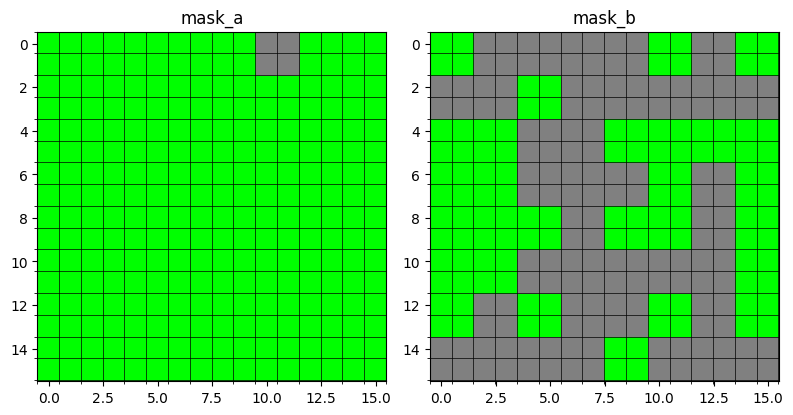

Frobenius norm: 4.28125
A.size() = torch.Size([4096, 4096])
B.size() = torch.Size([4096, 4096])
A has 4194304 non-zero entries (25.0%)
B has 4194304 non-zero entries (25.0%)
Replaced model.layers.0.self_attn.q_proj with FactorizedLinear (Bottleneck: 4096)
torch.Size([1024, 4096])
torch.Size([4096])
torch.Size([1024, 4096])
torch.Size([1024, 4096])


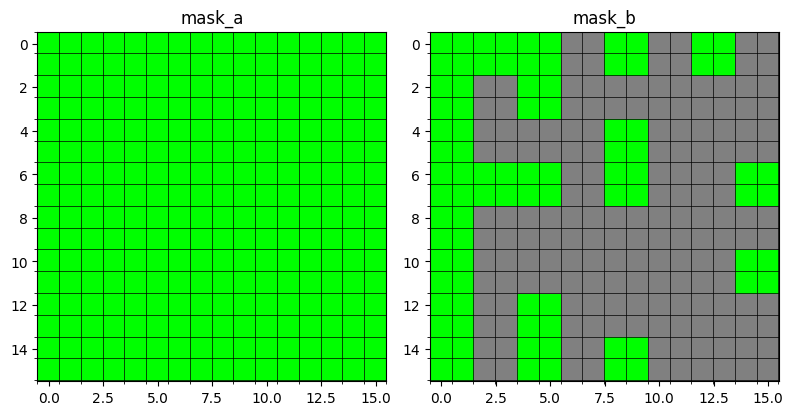

Frobenius norm: 3.53125
A.size() = torch.Size([1024, 1024])
B.size() = torch.Size([1024, 4096])
A has 1042430 non-zero entries (99.4%)
B has 1045774 non-zero entries (24.9%)
Replaced model.layers.0.self_attn.k_proj with FactorizedLinear (Bottleneck: 1024)
torch.Size([1024, 4096])
torch.Size([4096])
torch.Size([1024, 4096])
torch.Size([1024, 4096])


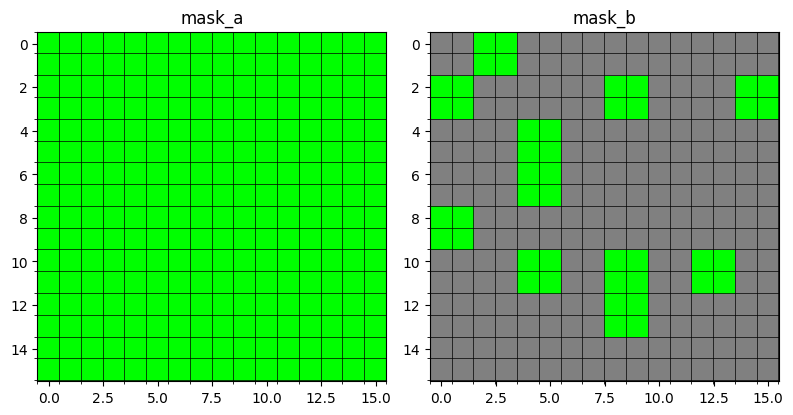

Frobenius norm: 3.765625
A.size() = torch.Size([1024, 1024])
B.size() = torch.Size([1024, 4096])
A has 1048572 non-zero entries (100.0%)
B has 1048576 non-zero entries (25.0%)
Replaced model.layers.0.self_attn.v_proj with FactorizedLinear (Bottleneck: 1024)
torch.Size([4096, 4096])
torch.Size([4096])
torch.Size([4096, 4096])
torch.Size([4096, 4096])


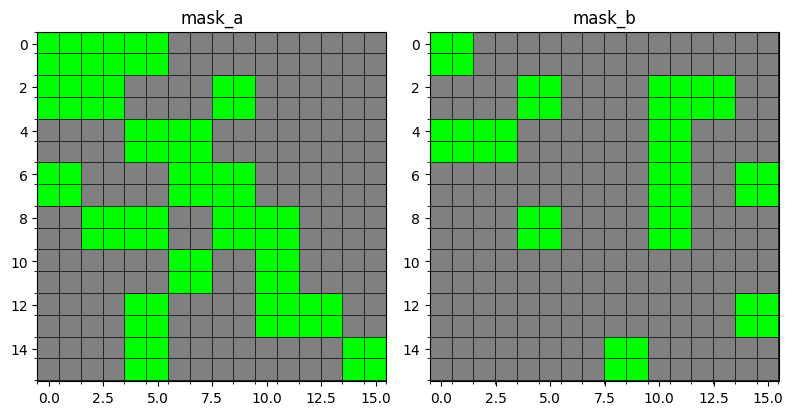

Frobenius norm: 7.78125
A.size() = torch.Size([4096, 4096])
B.size() = torch.Size([4096, 4096])
A has 4194304 non-zero entries (25.0%)
B has 4194304 non-zero entries (25.0%)
Replaced model.layers.0.self_attn.o_proj with FactorizedLinear (Bottleneck: 4096)
torch.Size([14336, 4096])
torch.Size([4096, 1])
torch.Size([4096, 14336])
torch.Size([4096, 14336])


OutOfMemoryError: CUDA out of memory. Tried to allocate 224.00 MiB. GPU 0 has a total capacity of 15.74 GiB of which 15.62 MiB is free. Including non-PyTorch memory, this process has 15.68 GiB memory in use. Of the allocated memory 15.07 GiB is allocated by PyTorch, and 447.39 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
class FactorizedLinear(nn.Sequential):
    '''Helper to wrap L and R into a single unit'''
    def __init__(self, layer_R, layer_L):
        super().__init__(layer_R, layer_L)

@torch.no_grad()
def prune_model(model):
    layers_to_replace = []
    for name, module in model.named_modules():
        if name == 'lm_head':
            continue
        if isinstance(module, nn.Linear):
            layers_to_replace.append((name, module))
    print(len(layers_to_replace))

    for name, layer in layers_to_replace:
        dtype = layer.weight.dtype
        W = layer.weight.data
        print(W.shape)

        XX = torch.eye(W.shape[1], device=W.device)
        prod, A, B = factorize(W, XX, mask_type='blocks', bsp=0.25, sp=0.5)
        mid_dim = A.shape[1]
        layer_R = nn.Linear(layer.in_features, mid_dim, bias=False, dtype=dtype)
        layer_L = nn.Linear(mid_dim, layer.out_features, bias=layer.bias is not None, dtype=dtype)

        frobenius = torch.norm(prod - W, p='fro')
        print(f'Frobenius norm: {frobenius.item()}')

        A_cpu = A.cpu()
        B_cpu = B.cpu()

        nz_count_A = torch.count_nonzero(A_cpu).item()
        nz_count_B = torch.count_nonzero(B_cpu).item()

        print(f'A.size() = {A_cpu.size()}')
        print(f'B.size() = {B_cpu.size()}')

        n_a = A_cpu.size(dim=0)
        m_a = A_cpu.size(dim=1)
        n_b = B_cpu.size(dim=0)
        m_b = B_cpu.size(dim=1)

        print(f'A has {nz_count_A} non-zero entries ({round(nz_count_A/(n_a*m_a)*100, 1)}%)')
        print(f'B has {nz_count_B} non-zero entries ({round(nz_count_B/(n_b*m_b)*100, 1)}%)')

        layer_R.weight.copy_(B.to(dtype))
        layer_L.weight.copy_(A.to(dtype))

        if '.' in name:
            parent_name, attr_name = name.rsplit('.', 1)
            parent = dict(model.named_modules())[parent_name]
        else:
            parent = model
            attr_name = name
            
        setattr(parent, attr_name, FactorizedLinear(layer_R, layer_L))
        print(f'Replaced {name} with FactorizedLinear (Bottleneck: {mid_dim})')
        torch.cuda.empty_cache()

prune_model(model)

In [ ]:
DEBUG = True

import transformers

class DoubleSparse:
    def __init__(self, layer, nofinal=True):
        self.layer = layer
        self.dev = self.layer.weight.device
        W = layer.weight.data.clone()
        if isinstance(self.layer, nn.Conv2d):
            W = W.flatten(1)
        if isinstance(self.layer, transformers.Conv1D):
            W = W.t()
        self.rows = W.shape[0]
        self.columns = W.shape[1]
        self.H = torch.zeros((self.columns, self.columns), device=self.dev)
        self.nsamples = 0
        self.nofinal = nofinal

    def add_batch(self, inp, out):
        if DEBUG:
            self.inp1 = inp
            self.out1 = out
        if len(inp.shape) == 2:
            inp = inp.unsqueeze(0)
        tmp = inp.shape[0]
        if isinstance(self.layer, nn.Linear) or isinstance(self.layer, transformers.Conv1D):
            if len(inp.shape) == 3:
                inp = inp.reshape((-1, inp.shape[-1]))
            inp = inp.t()
        self.H *= self.nsamples / (self.nsamples + tmp)
        self.nsamples += tmp
        inp = math.sqrt(2 / self.nsamples) * inp.float()
        self.H += inp.matmul(inp.t())

    def fasterprune(self, sparsity):
        W = self.layer.weight.data.clone()
        W = W.float()
        tick = time.time()

        W2, _, _ = factorize(W, self.H, sparsity, nofinal=self.nofinal, fixmask=None)

        torch.cuda.synchronize()
        print('time %.2f' % (time.time() - tick))

        self.layer.weight.data = W2.reshape(self.layer.weight.shape).to(self.layer.weight.data.dtype)
        if DEBUG:
            print(torch.sum((self.layer(self.inp1) - self.out1) ** 2))

    def free(self):
        if DEBUG:
            self.inp1 = None
            self.out1 = None
        self.H = None
        torch.cuda.empty_cache()


In [ ]:
from datasets import load_dataset
import random


def get_wikitext2(nsamples, seed, seqlen, tokenizer):
    traindata = load_dataset('wikitext', 'wikitext-2-raw-v1', split='train')
    testdata = load_dataset('wikitext', 'wikitext-2-raw-v1', split='test')

    trainenc = tokenizer(" ".join(traindata['text']), return_tensors='pt')
    testenc = tokenizer("\n\n".join(testdata['text']), return_tensors='pt')

    random.seed(seed)
    trainloader = []
    for _ in range(nsamples):
        i = random.randint(0, trainenc.input_ids.shape[1] - seqlen - 1)
        j = i + seqlen
        inp = trainenc.input_ids[:, i:j]
        tar = inp.clone()
        tar[:, :-1] = -100
        trainloader.append((inp, tar))
    return trainloader, testenc


def get_c4(nsamples, seed, seqlen, tokenizer):
    traindata = load_dataset(
        'allenai/c4', data_files={'train': 'en/c4-train.00000-of-01024.json.gz'}, split='train'
    )
    valdata = load_dataset(
        'allenai/c4', data_files={'validation': 'en/c4-validation.00000-of-00008.json.gz'}, split='validation'
    )

    random.seed(seed)
    trainloader = []
    for _ in range(nsamples):
        while True:
            i = random.randint(0, len(traindata) - 1)
            trainenc = tokenizer(traindata[i]['text'], return_tensors='pt')
            if trainenc.input_ids.shape[1] > seqlen:
                break
        i = random.randint(0, trainenc.input_ids.shape[1] - seqlen - 1)
        j = i + seqlen
        inp = trainenc.input_ids[:, i:j]
        tar = inp.clone()
        tar[:, :-1] = -100
        trainloader.append((inp, tar))

    valenc = tokenizer(' '.join(valdata[:1100]['text']), return_tensors='pt')
    valenc = valenc.input_ids[:, :(256 * seqlen)]

    class TokenizerWrapper:
        def __init__(self, input_ids):
            self.input_ids = input_ids
    valenc = TokenizerWrapper(valenc)

    return trainloader, valenc


Generating validation split: 100%|██████████| 3760/3760 [00:00<00:00, 391815.73 examples/s]
Generating train split: 356317 examples [00:06, 58425.44 examples/s]
Generating validation split: 45576 examples [00:00, 59727.46 examples/s]


In [ ]:
# Calibration on C4

NSAMPLES = 128
NO_FINAL = True
SPARSITY = 0.5

import wandb

def find_layers(module, layers=[nn.Conv2d, nn.Linear], name=''):
    if type(module) in layers:
        return {name: module}
    res = {}
    for name1, child in module.named_children():
        res.update(find_layers(
            child, layers=layers, name=name + '.' + name1 if name != '' else name1
        ))
    return res

@torch.no_grad()
def llama_sequential(model):
    print("Starting...")

    use_cache = model.config.use_cache
    model.config.use_cache = False
    layers = model.model.layers

    dtype = next(iter(model.parameters())).dtype
    inps = torch.zeros(
        (NSAMPLES, model.seqlen, model.config.hidden_size), dtype=dtype, device="cuda"
    )
    cache = {"i": 0, "attention_mask": None}

    class Catcher(nn.Module):
        def __init__(self, module):
            super().__init__()
            self.module = module

        def forward(self, inp, **kwargs):
            inps[cache["i"]] = inp
            cache["i"] += 1
            cache["attention_mask"] = kwargs["attention_mask"]
            raise ValueError

    layers[0] = Catcher(layers[0])
    layers[0] = layers[0].module
    layers[0] = layers[0].cpu()
    model.model.embed_tokens = model.model.embed_tokens.cpu()
    model.model.norm = model.model.norm.cpu()
    torch.cuda.empty_cache()

    outs = torch.zeros_like(inps)
    attention_mask = cache["attention_mask"]

    print("Ready.")

    quantizers = {}
    for i in range(len(layers)):
        layer = layers[i]
        full = find_layers(layer)
        sequential = [list(full.keys())]

        for names in sequential:
            subset = {n: full[n] for n in names}
            gpts = {}
            for name in subset:
                gpts[name] = DoubleSparse(subset[name], nofinal=NO_FINAL, fixmask=None)

            def add_batch(name):
                def tmp(_, inp, out):
                    gpts[name].add_batch(inp[0].data, out.data)

                return tmp

            handles = []
            for name in subset:
                handles.append(subset[name].register_forward_hook(add_batch(name)))
            for j in range(NSAMPLES):
                outs[j] = layer(inps[j].unsqueeze(0), attention_mask=attention_mask)[0]
            for h in handles:
                h.remove()
            del outs

            for name in subset:
                print(i, name)
                print("Pruning ...")
                sparsity = SPARSITY
                gpts[name].fasterprune(sparsity)
                gpts[name].free()

        outs = torch.zeros_like(inps)
        for j in range(NSAMPLES):
            outs[j] = layer(inps[j].unsqueeze(0), attention_mask=attention_mask)[0]

        layers[i] = layer.cpu()
        del layer
        del gpts
        torch.cuda.empty_cache()

        inps, outs = outs, inps

    model.config.use_cache = use_cache
    return quantizers



In [ ]:
# Evaluation on Wikitext2

@torch.no_grad()
def llama_eval(model, testenc, dataset: str, log_wandb: bool = False):
    print("Evaluating ...")

    testenc = testenc.input_ids
    nsamples = testenc.numel() // model.seqlen

    use_cache = model.config.use_cache
    model.config.use_cache = False
    layers = model.model.layers

    dtype = next(iter(model.parameters())).dtype
    inps = torch.zeros(
        (nsamples, model.seqlen, model.config.hidden_size), dtype=dtype, device="cuda"
    )
    cache = {"i": 0, "attention_mask": None}

    class Catcher(nn.Module):
        def __init__(self, module):
            super().__init__()
            self.module = module

        def forward(self, inp, **kwargs):
            inps[cache["i"]] = inp
            cache["i"] += 1
            cache["attention_mask"] = kwargs["attention_mask"]
            raise ValueError

    layers[0] = Catcher(layers[0])
    for i in range(nsamples):
        batch = testenc[:, (i * model.seqlen) : ((i + 1) * model.seqlen)]
        try:
            model(batch)
        except ValueError:
            pass
    layers[0] = layers[0].module

    layers[0] = layers[0].cpu()
    model.model.embed_tokens = model.model.embed_tokens.cpu()
    torch.cuda.empty_cache()

    outs = torch.zeros_like(inps)
    attention_mask = cache["attention_mask"]

    for i in range(len(layers)):
        print(i)
        layer = layers[i]

        for j in range(nsamples):
            outs[j] = layer(inps[j].unsqueeze(0), attention_mask=attention_mask)[0]
        layers[i] = layer.cpu()
        del layer
        torch.cuda.empty_cache()
        inps, outs = outs, inps

    nlls = []
    for i in range(nsamples):
        hidden_states = inps[i].unsqueeze(0)
        if model.model.norm is not None:
            hidden_states = model.model.norm(hidden_states)
        lm_logits = model.lm_head(hidden_states)
        shift_logits = lm_logits[:, :-1, :].contiguous()
        shift_labels = testenc[:, (i * model.seqlen) : ((i + 1) * model.seqlen)][:, 1:]
        loss_fct = nn.CrossEntropyLoss()
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1)
        )
        neg_log_likelihood = loss.float() * model.seqlen
        nlls.append(neg_log_likelihood)
        
    ppl = torch.exp(torch.stack(nlls).sum() / (nsamples * model.seqlen))
    print(f"Perplexity: {ppl.item():3f}")
    if log_wandb:
        wandb.log({f"{dataset}/perplexity": ppl.item()})

    model.config.use_cache = use_cache


if __name__ == "__main__":
    from datautils import *

    wandb.init()
    model.eval()
    dataloader, testloader = get_c4(NSAMPLES, seed=42, seqlen=model.seqlen, tokenizer=tokenizer)

    tick = time.time()
    llama_sequential(model, dataloader)
    for n, p in model.named_parameters():
        print(n, torch.mean((p == 0).float()))
        if 'down_proj' in n:
            break
    print(time.time() - tick)

    dataloader, testloader = get_wikitext2(NSAMPLES, seed=42, seqlen=model.seqlen, tokenizer=tokenizer)
    llama_eval(model, testloader, "wikitext2", log_wandb=True)

    filepath = "./pruned/"
    model.save_pretrained(filepath)

# TODO prepare pipeline
# TODO test pipeline
# TODO fix pipeline

Cleanup:

In [ ]:
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()